# Fastest-Growing Regions for Counter-Strike

**Purpose:** generalizes `notebooks/china_cs_scene.ipynb`'s single-country
approach across every country with usable data, to answer directly: which
regions are actually growing fastest for Counter-Strike, and by which
measure? China motivated this notebook (its grassroots tournament *count*
looked like a growth story at first), but the honest answer turns out to
be more specific than "China is growing fastest" -- see §7.

**Method, stated up front**: compares an EARLY window (2016-2018) against
a RECENT window (2023-2025), skipping 2019-2022 entirely rather than using
year-over-year deltas. Several countries (China chief among them, see
`china_cs_scene.ipynb` §3) went through a sharp COVID-era collapse to zero
and back -- a year-over-year comparison would be dominated by exactly
where in that whipsaw each comparison year happened to fall. A clean
before/after comparison across the gap is more informative for "has this
country's scene structurally grown," at the cost of being blind to
anything that happened only in the skipped years. A minimum-N threshold on
the EARLY period excludes countries where a small base would make the
growth *ratio* meaningless (a country with 1 event becoming 2 "doubles"
without that meaning anything) -- those show up separately as **new
entrants** instead, which is where some of the most interesting stories
turn out to be.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110

EARLY = ("2016", "2019")
RECENT = ("2023", "2026")

## 1. Country mapping

Reuses `title_geography_maps.ipynb`'s `COUNTRY_TO_ISO3`/`EXCLUDED_COUNTRY`
mapping, with `grassroots_scene_comparison.ipynb`'s extensions (Baltic
states, the Balkans, several MENA countries -- needed for grassroots
data's longer geographic tail).

In [2]:
# ISO-3 mapping, keyed on the lowercased raw string. Covers every genuine
# country/alias/2-letter-code actually observed in tournaments.country --
# built and tested against the real distinct-value distribution, not
# guessed at scale (tested: 8,429 of 16,300 tier-1/2 rows with a country
# value map cleanly, 7,870 are real continents/regions/placeholders
# (EXCLUDED_COUNTRY, below), and exactly 1 row -- "bs", genuinely
# ambiguous between Bahamas and Bosnia -- falls through unmapped).
COUNTRY_TO_ISO3 = {
    "united states": "USA", "usa": "USA", "us": "USA", "united states of america": "USA",
    "china": "CHN", "cn": "CHN",
    "south korea": "KOR", "korea": "KOR", "kr": "KOR",
    "brazil": "BRA", "brasil": "BRA", "br": "BRA",
    "japan": "JPN", "jp": "JPN",
    "germany": "DEU", "de": "DEU",
    "france": "FRA", "fr": "FRA",
    "taiwan": "TWN", "tw": "TWN",
    "sweden": "SWE", "se": "SWE",
    "australia": "AUS",
    "vietnam": "VNM", "vn": "VNM",
    "united kingdom": "GBR", "uk": "GBR", "england": "GBR", "scotland": "GBR",
    "thailand": "THA", "th": "THA",
    "malaysia": "MYS", "my": "MYS",
    "saudi arabia": "SAU", "sa": "SAU",
    "indonesia": "IDN",
    "canada": "CAN", "ca": "CAN",
    "india": "IND",
    "russia": "RUS", "ru": "RUS",
    "mexico": "MEX", "méxico": "MEX", "mx": "MEX",
    "philippines": "PHL",
    "poland": "POL", "pl": "POL",
    "ukraine": "UKR", "ua": "UKR",
    "turkey": "TUR", "turkiye": "TUR", "türkiye": "TUR", "tr": "TUR",
    "spain": "ESP", "es": "ESP",
    "finland": "FIN",
    "romania": "ROU", "ro": "ROU",
    "chile": "CHL",
    "italy": "ITA",
    "pakistan": "PAK",
    "netherlands": "NLD", "nl": "NLD",
    "united arab emirates": "ARE", "ae": "ARE",
    "south africa": "ZAF",
    "hong kong": "HKG",
    "peru": "PER",
    "belgium": "BEL",
    "denmark": "DNK", "dk": "DNK",
    "cambodia": "KHM",
    "norway": "NOR", "no": "NOR",
    "dominican republic": "DOM",
    "argentina": "ARG",
    "puerto rico": "PRI",
    "myanmar": "MMR",
    "ireland": "IRL", "ie": "IRL",
    "macau": "MAC",
    "kazakhstan": "KAZ",
    "greece": "GRC",
    "bulgaria": "BGR",
    "austria": "AUT", "at": "AUT",
    "bangladesh": "BGD",
    "costa rica": "CRI",
    "colombia": "COL",
    "portugal": "PRT",
    "belarus": "BLR", "by": "BLR",
    "azerbaijan": "AZE",
    "uzbekistan": "UZB",
    "serbia": "SRB",
    "new zealand": "NZL",
    "croatia": "HRV",
    "armenia": "ARM",
    "switzerland": "CHE", "ch": "CHE",
    "nepal": "NPL",
    "malta": "MLT",
    "madagascar": "MDG",
    "ivory coast": "CIV",
    "bolivia": "BOL",
    "qatar": "QAT",
    "mongolia": "MNG", "mn": "MNG",
    "laos": "LAO",
    "hungary": "HUN",
    "georgia": "GEO",
    "czech republic": "CZE", "czechia": "CZE", "cz": "CZE",
    "sint maarten": "SXM",
    "maldives": "MDV",
    "kuwait": "KWT",
    "israel": "ISR",
    "iran": "IRN",
    "iceland": "ISL",
    "brunei": "BRN",
    "venezuela": "VEN",
    "turkmenistan": "TKM",
    "tajikistan": "TJK",
    "slovenia": "SVN",
    "slovakia": "SVK", "sk": "SVK",
    "panama": "PAN",
    "morocco": "MAR",
    "lithuania": "LTU",
    "kyrgyzstan": "KGZ",
    "jordan": "JOR",
    "egypt": "EGY",
    "cyprus": "CYP",
    "andorra": "AND",
    "singapore": "SGP", "sg": "SGP",
}

# Continents, macro-regions, and placeholders -- real values, but not a
# single country, so excluded rather than force-mapped to one arbitrary
# member. "kosovo" included here too: a real place, but no standard ISO-3
# code in plotly's built-in reference.
EXCLUDED_COUNTRY = {
    "north america", "europe", "world", "south america", "asia", "oceania",
    "southeast asia", "middle east", "cis", "americas", "africa", "mena",
    "asia-pacific", "south asia", "latin america", "apac", "east asia",
    "sea", "latin america north", "emea", "central america", "latam",
    "global", "northeast asia", "asia pacific", "sub-saharan africa",
    "middle east and north africa", "oce", "eu", "benelux", "nordic",
    "nordics", "western europe", "eastern europe", "latin america south",
    "las", "lan", "tbd", "north americas", "kosovo",
}

EXTRA_COUNTRY_TO_ISO3 = {
    "latvia": "LVA", "estonia": "EST", "bosnia and herzegovina": "BIH",
    "lebanon": "LBN", "albania": "ALB", "north macedonia": "MKD",
    "macedonia": "MKD", "czech": "CZE", "sri lanka": "LKA", "ecuador": "ECU",
    "algeria": "DZA", "tunisia": "TUN", "montenegro": "MNE", "moldova": "MDA",
    "paraguay": "PRY", "mauritius": "MUS", "uruguay": "URY", "cuba": "CUB",
    "wales": "GBR", "perú": "PER", "au": "AUS",
    "guatemala": "GTM", "syria": "SYR", "uae": "ARE", "nigeria": "NGA",
    "senegal": "SEN", "faroe islands": "FRO", "bahrain": "BHR", "iraq": "IRQ",
    "palestine": "PSE", "bg": "BGR", "ph": "PHL", "martinique": "MTQ",
    "kazakhstan": "KAZ", "uzbekistan": "UZB",
}
COUNTRY_TO_ISO3.update(EXTRA_COUNTRY_TO_ISO3)

def by_country(tier_filter, lo, hi, extra_cols=""):
    rows = conn.execute(
        f"SELECT country{extra_cols} FROM tournaments WHERE title_id='counter_strike' "
        f"AND {tier_filter} AND country IS NOT NULL AND start_date >= ? AND start_date < ?",
        (lo, hi),
    ).fetchall()
    cols = ["country_raw"] + [c.strip() for c in extra_cols.split(",") if c.strip()]
    df = pd.DataFrame(rows, columns=cols)
    df["key"] = df["country_raw"].str.strip().str.lower()
    df["iso3"] = df["key"].map(COUNTRY_TO_ISO3)
    return df[df["iso3"].notna()]

GRASSROOTS = "tier NOT IN ('S-Tier','A-Tier')"
TIER12 = "tier IN ('S-Tier','A-Tier')"

print("Setup complete.")

Setup complete.


## 2. Grassroots tournament count — who's actually growing fastest

The richest-volume signal (thousands of events/country in some cases), so
the growth *ratio* is meaningful here in a way it won't be for tier-1/2's
much smaller numbers.

In [3]:
def grassroots_counts(lo, hi):
    df = by_country(GRASSROOTS, lo, hi)
    return df["iso3"].value_counts()

g_early = grassroots_counts(*EARLY)
g_recent = grassroots_counts(*RECENT)
g_growth = pd.DataFrame({"early": g_early, "recent": g_recent}).fillna(0)
g_growth["ratio"] = g_growth["recent"] / g_growth["early"].replace(0, pd.NA)

established = g_growth[g_growth["early"] >= 15].sort_values("ratio", ascending=False)
print("Established scenes (>=15 events in 2016-18), ranked by growth ratio:")
print(established.head(12).to_string())

new_entrants = g_growth[(g_growth["early"] < 5) & (g_growth["recent"] >= 15)].sort_values("recent", ascending=False)
print("\nNew entrants (near-zero in 2016-18, >=15 events by 2023-25):")
print(new_entrants.to_string())

Established scenes (>=15 events in 2016-18), ranked by growth ratio:
      early  recent     ratio
iso3                         
RUS    41.0    75.0  1.829268
CZE    22.0    37.0  1.681818
ARG    19.0    30.0  1.578947
ZAF    37.0    46.0  1.243243
CHN   170.0   185.0  1.088235
PRT    34.0    37.0  1.088235
GBR    50.0    50.0       1.0
NOR    22.0    20.0  0.909091
FIN    38.0    29.0  0.763158
USA    36.0    27.0      0.75
VNM    15.0    10.0  0.666667
DEU    69.0    40.0   0.57971

New entrants (near-zero in 2016-18, >=15 events by 2023-25):
      early  recent ratio
iso3                     
KAZ     1.0    37.0  37.0
UZB     0.0    25.0  <NA>


**The real fastest growers, by tournament count, are not China.**
Among established scenes, Russia (1.83x), Czech Republic (1.68x),
Argentina (1.58x), and South Africa (1.24x) grew fastest. China does grow
(170 → 185 events) but only **1.09x** — modest relative growth on an
already-huge base, not a fast grower in relative terms. The real headline
growth story is two countries with almost no grassroots presence in
2016-18: **Kazakhstan (1 → 37 events) and Uzbekistan (0 → 25 events)** —
both essentially new Central Asian scenes emerging within this window,
unconnected to anything already documented in this project.

## 3. Tier-1/2 tournament count — prestige hosting

Much sparser (single or low-double-digit events per country over 3 years),
so ratios are noisier and a lower threshold is used. China's own ratio
here (0.6x, a decline) needs a caveat before being read at face value.

In [4]:
def tier12_counts(lo, hi):
    df = by_country(TIER12, lo, hi)
    return df["iso3"].value_counts()

t_early = tier12_counts(*EARLY)
t_recent = tier12_counts(*RECENT)
t_growth = pd.DataFrame({"early": t_early, "recent": t_recent}).fillna(0)
t_growth["ratio"] = t_growth["recent"] / t_growth["early"].replace(0, pd.NA)

established = t_growth[t_growth["early"] >= 3].sort_values("ratio", ascending=False)
print("Established tier-1/2 hosts (>=3 events in 2016-18), ranked by growth ratio:")
print(established.to_string())

new_entrants = t_growth[(t_growth["early"] < 2) & (t_growth["recent"] >= 3)].sort_values("recent", ascending=False)
print("\nNew tier-1/2 entrants:")
print(new_entrants.to_string())

Established tier-1/2 hosts (>=3 events in 2016-18), ranked by growth ratio:
      early  recent     ratio
iso3                         
DNK     6.0    13.0  2.166667
AUS     3.0     4.0  1.333333
POL     7.0     6.0  0.857143
ROU     9.0     6.0  0.666667
CHN    15.0     9.0       0.6
DEU     7.0     4.0  0.571429
SWE    11.0     6.0  0.545455
USA    38.0    10.0  0.263158
ESP     4.0     1.0      0.25
FRA     5.0     1.0       0.2
GBR    13.0     2.0  0.153846
CAN     5.0     0.0       0.0
MYS     3.0     0.0       0.0
RUS     7.0     0.0       0.0
UKR     8.0     0.0       0.0

New tier-1/2 entrants:
      early  recent ratio
iso3                     
MLT     1.0     7.0   7.0
SRB     1.0     6.0   6.0
IND     0.0     5.0  <NA>
ARE     1.0     4.0   4.0
MNG     0.0     3.0  <NA>
SAU     0.0     3.0  <NA>


**Denmark leads established hosts** (6 → 13 events, 2.17x) — a real,
if modest-scale, prestige-hosting growth story with no other documentation
in this project yet. **A wave of genuinely new tier-1/2 hosts** emerges:
Malta (1→7), Serbia (1→6), UAE (1→4), and complete newcomers India,
Mongolia, and Saudi Arabia (0→3-5 each) — several of these (Saudi Arabia
especially) connect directly to `docs/counter_strike_lifecycle_brief.md`
§9-§11's already-documented Saudi-backed event lineage (Gamers Without
Borders, Gamers8, EWC), now visible here as a hosting-footprint expansion
too, not just a prize-pool one.

**China's own 0.6x ratio here needs a direct caveat, not a bare number**:
this EARLY/EXCLUDE-middle/RECENT window happens to fall awkwardly across
China's own volatile pattern (`china_cs_scene.ipynb` §2-§3) -- 2016-18
captures part of the WESG boom's rise, while 2023-25 captures the *early*
recovery years, missing 2026's actual record-breaking total entirely
(2026 is excluded from this notebook's RECENT window by construction,
since it's still partial). Read China's tier-1/2 trajectory from its own
dedicated notebook, not this ratio -- this is exactly the kind of
single-number distortion the windowing choice was meant to avoid for
*most* countries, but a two-collapse pattern this specific breaks even a
skip-the-middle comparison.

## 4. Why prize money can't be compared *across countries* here

Checked directly before attempting it, the same way currency contamination
was checked in `grassroots_scene_comparison.ipynb` §1 -- and this time the
check finds a real problem, not a clean bill of health.

In [5]:
for country_name, iso3 in [("Germany", "DEU"), ("Denmark", "DNK"), ("Australia", "AUS")]:
    rows = conn.execute(
        "SELECT currency, count(*), sum(prize_pool) FROM tournaments "
        "WHERE title_id='counter_strike' AND tier NOT IN ('S-Tier','A-Tier') AND country=? "
        "AND start_date >= '2023' AND start_date < '2026' AND prize_pool IS NOT NULL "
        "GROUP BY currency",
        (country_name,),
    ).fetchall()
    print(f"{country_name} (2023-25) prize_pool by currency:", rows)

Germany (2023-25) prize_pool by currency: [('eur', 27, 178717.41999999998)]
Denmark (2023-25) prize_pool by currency: [('DKK', 3, 145000.0), ('dkk', 9, 587500.0)]
Australia (2023-25) prize_pool by currency: [('aud', 6, 53000.0)]


**A real, country-correlated bias, not noise.** Germany's entire
2023-25 grassroots prize pool is denominated in EUR, Denmark's in DKK,
Australia's in AUD — **zero** of it in USD. The `currency='USD' OR
currency IS NULL` convention this project uses everywhere else (validated
clean for the aggregate, cross-title case in `grassroots_scene_comparison.
ipynb` §1) would silently zero out these countries' entire recent prize
money, not because they stopped paying prizes, but because local-currency
reporting has apparently become more common in some regions' grassroots
scenes over time. **A per-country prize-money growth ranking would be
comparing "who still reports in USD" as much as "who grew" — actively
misleading, not just noisy — so it isn't built here.** This project has no
currency-conversion pipeline (checked: no FX-rate table or dependency
anywhere in this codebase) to fix this properly. The valid money-trend
statement this project can make is the *aggregate* one already in
`grassroots_scene_comparison.ipynb` §6-§7 (total and average-per-event
prize money, both currency-checked at the aggregate level) — not a
per-country breakdown.

## 5. Participant-slots — this is where China's growth story actually is

`team_number` (sum of per-event team counts, not unique teams — same
standing caveat as `grassroots_scene_comparison.ipynb` §3) has no currency
problem, so it's usable for a direct cross-country comparison.

In [6]:
def slots(lo, hi):
    df = by_country(GRASSROOTS, lo, hi, extra_cols=", team_number")
    df = df[df["team_number"].notna()]
    return df.groupby("iso3")["team_number"].sum()

s_early = slots(*EARLY)
s_recent = slots(*RECENT)
s_growth = pd.DataFrame({"early": s_early, "recent": s_recent}).fillna(0)
s_growth["ratio"] = s_growth["recent"] / s_growth["early"].replace(0, pd.NA)

established = s_growth[s_growth["early"] >= 300].sort_values("ratio", ascending=False)
print("Participant-slots growth (>=300 slots in 2016-18):")
print(established.head(10).round(0).to_string())

Participant-slots growth (>=300 slots in 2016-18):
       early   recent      ratio
iso3                            
CHN   2684.0  30059.0  11.199329
UKR    329.0    417.0   1.267477
USA    464.0    585.0   1.260776
MNG    304.0    273.0   0.898026
ZAF    528.0    377.0   0.714015
BRA   2507.0   1630.0   0.650179
RUS   2485.0   1573.0   0.632998
FIN    327.0    205.0   0.626911
HKG    302.0    188.0   0.622517
GBR   1375.0    804.0   0.584727


**China's real growth story: an 11.2x jump in participant-slots**
(2,684 → 30,059) — an order of magnitude ahead of the next fastest grower
(Ukraine, 1.27x). This is the mega-open-qualifier phenomenon
`grassroots_scene_comparison.ipynb` §3 already found (China's China/Asia-
Pacific open brackets running into the thousands of entrants, e.g. one
2024 Perfect World qualifier alone had 8,643 teams) — not a broader,
more-events-everywhere kind of growth, a small number of very large
brackets. So: China isn't the fastest-growing region by tournament count
(§2 — modest at 1.09x) or reliably comparable by prize money (§4), but it
*is* the standout by a wide margin on participation scale specifically.
"Fastest growing" genuinely depends on which question is being asked.

## 6. Audience language-mix — a current snapshot, not a growth measure

Twitch data cannot be backfilled (CLAUDE.md's "one rule"), so this
project's own live-collected `language_mix_snapshots` only covers
2026-08-31 onward — too short a window to measure growth. Shown here as a
**current cross-sectional check only**: do the countries growing on the
hosting/participation side also show up as meaningful Twitch audiences
today?

In [7]:
LANGUAGE_TO_COUNTRY = {
    "ko": "KOR", "ja": "JPN", "th": "THA", "vi": "VNM", "id": "IDN", "tl": "PHL",
    "hi": "IND", "ms": "MYS", "he": "ISR",
    "ru": "RUS", "de": "DEU", "fr": "FRA", "it": "ITA", "pl": "POL", "tr": "TUR",
    "uk": "UKR", "cs": "CZE", "hu": "HUN", "el": "GRC", "fi": "FIN", "sv": "SWE",
    "da": "DNK", "no": "NOR", "nl": "NLD", "ro": "ROU", "bg": "BGR", "sk": "SVK",
    "hr": "HRV", "pt": "BRA",
}
AMBIGUOUS = {"en", "es", "zh", "ar", "other"}

lang_rows = conn.execute(
    "SELECT language_code, SUM(viewer_count) AS vt FROM language_mix_snapshots "
    "WHERE title_id='counter_strike' GROUP BY language_code"
).fetchall()
lang_df = pd.DataFrame(lang_rows, columns=["lang", "viewer_time"])
lang_df["iso3"] = lang_df["lang"].map(LANGUAGE_TO_COUNTRY)
total = lang_df["viewer_time"].sum()
lang_df["share_pct"] = lang_df["viewer_time"] / total * 100

mapped_pct = lang_df[lang_df["iso3"].notna()]["share_pct"].sum()
print(f"{mapped_pct:.0f}% of CS viewer-time maps to a specific country\n")
print(lang_df[lang_df["iso3"].notna()].sort_values("share_pct", ascending=False)[["iso3","lang","share_pct"]].head(10).round(2).to_string(index=False))

zh_share = lang_df[lang_df["lang"] == "zh"]["share_pct"].iloc[0]
print(f"\nChinese-language ('zh') share of CS viewer-time: {zh_share:.2f}% -- excluded from country mapping (ambiguous: China, Taiwan, Hong Kong, Singapore, diaspora)")

74% of CS viewer-time maps to a specific country

iso3 lang  share_pct
 RUS   ru      51.55
 BRA   pt       7.95
 POL   pl       5.11
 FRA   fr       2.63
 DEU   de       1.61
 UKR   uk       1.37
 FIN   fi       1.07
 SWE   sv       0.52
 ITA   it       0.44
 HUN   hu       0.36

Chinese-language ('zh') share of CS viewer-time: 0.25% -- excluded from country mapping (ambiguous: China, Taiwan, Hong Kong, Singapore, diaspora)


**Russia dominates** (51.6% of all mappable CS viewer-time on
Twitch) — far beyond any other country, consistent with its established
reputation and with §2's finding that Russia is also among the fastest-
growing grassroots hosts by count. Czech Republic, despite leading §2's
established-scene growth ranking (1.68x), barely registers here (0.05%) —
its growth is in hosting/organizing infrastructure, not (yet, or ever) a
large domestic Twitch audience.

**China is structurally invisible on this axis, and that's worth stating
plainly rather than leaving as a silent gap**: Chinese-language viewership
is only 0.25% of all CS viewer-time on Twitch, and even that tiny sliver
is excluded from country-mapping as ambiguous (Chinese is spoken across
several countries/territories). This isn't evidence China's CS audience is
small — PRD §9.8 already established that Twitch itself is not meaningfully
accessible in China, so Chinese viewers who exist mostly wouldn't show up
here regardless of scale. The hosting-side growth (§5) and the audience-
side blank spot are two different facts, not a contradiction.

## 7. Synthesis — there is no single "fastest-growing region"

Four independent signals, four different leaders. Shown together rather
than forced into one ranking, because forcing one would hide the real
finding.

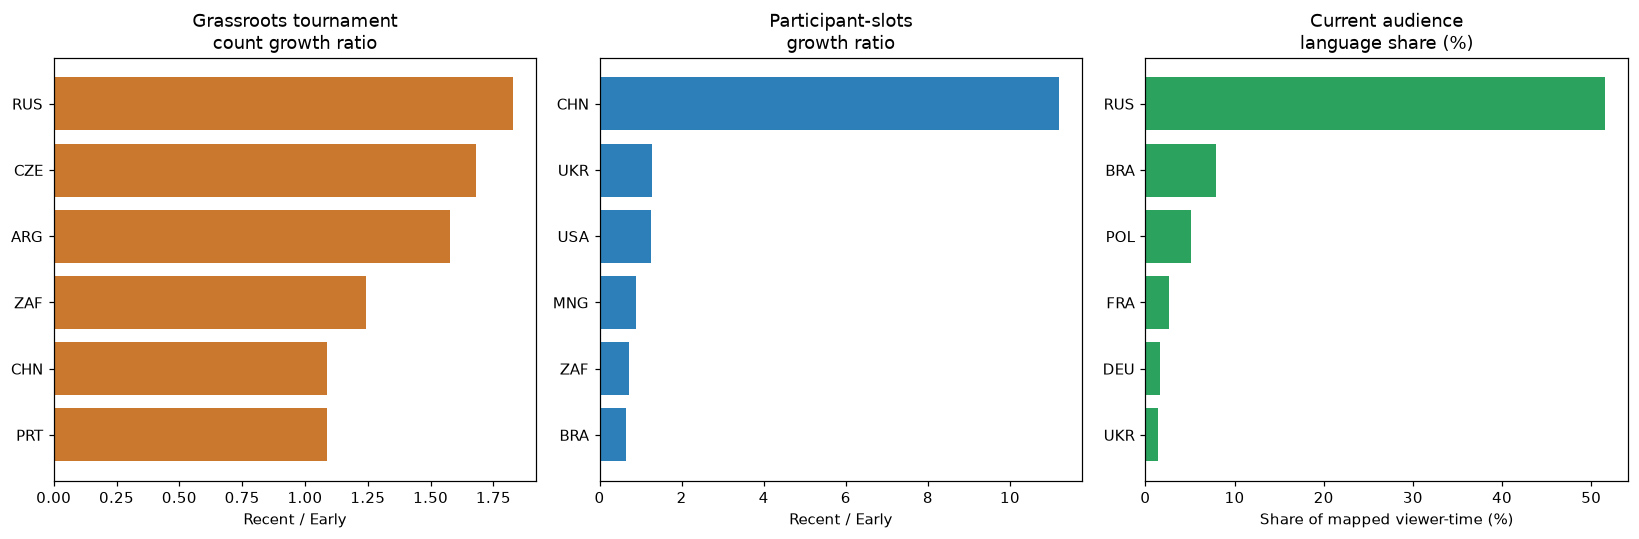

In [8]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

top_count = g_growth[g_growth["early"] >= 15].sort_values("ratio", ascending=False).head(6)
axes[0].barh(top_count.index[::-1], top_count["ratio"][::-1], color="#c9782e")
axes[0].set_title("Grassroots tournament\ncount growth ratio")
axes[0].set_xlabel("Recent / Early")

top_slots = s_growth[s_growth["early"] >= 300].sort_values("ratio", ascending=False).head(6)
axes[1].barh(top_slots.index[::-1], top_slots["ratio"][::-1], color="#2c7fb8")
axes[1].set_title("Participant-slots\ngrowth ratio")
axes[1].set_xlabel("Recent / Early")

top_lang = lang_df[lang_df["iso3"].notna()].sort_values("share_pct", ascending=False).head(6)
axes[2].barh(top_lang["iso3"][::-1], top_lang["share_pct"][::-1], color="#2ca25f")
axes[2].set_title("Current audience\nlanguage share (%)")
axes[2].set_xlabel("Share of mapped viewer-time (%)")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_regions_fig_synthesis.png", dpi=110)
plt.show()

| Signal | Leader | China's position |
|---|---|---|
| Grassroots tournament count growth | Russia (1.83x) | Modest (1.09x) — huge base, not fast-growing in relative terms |
| Grassroots participant-slots growth | **China (11.2x)** | Standout leader by a wide margin |
| Tier-1/2 hosting growth | Denmark (2.17x) | Distorted by its own two-collapse pattern — see `china_cs_scene.ipynb` |
| New entrants (from ~0) | Kazakhstan, Uzbekistan (grassroots); Malta, Serbia, India, Mongolia, Saudi Arabia (tier-1/2) | Not a new entrant — already the largest scene in the early period too |
| Current audience language share | Russia (51.6%) | Structurally invisible (Twitch inaccessible in China) — not measured, not absent |

Reliable cross-country prize-money growth isn't in this table at all —
§4 found the comparison itself is invalid without a currency-conversion
capability this project doesn't have.

## 8. Bottom line

"Fastest-growing region for Counter-Strike" doesn't have one answer — it
depends entirely on what's being measured, and this project can measure
four genuinely different things. By raw tournament *count*, the fastest
established growers are Russia, Czech Republic, Argentina, and South
Africa, and the real headline story is two near-zero-to-real emergences,
Kazakhstan and Uzbekistan — not previously documented anywhere in this
project. By *participation scale*, China is the overwhelming outlier
(11.2x) — but driven by a specific mechanism (a small number of massive
open-bracket qualifiers, `grassroots_scene_comparison.ipynb` §3), not
broad-based growth in the number of distinct events. By tier-1/2 *prestige
hosting*, Denmark leads among established hosts, and a real wave of new
hosts is emerging (Malta, Serbia, UAE, India, Mongolia, Saudi Arabia — several
connected to the brief's own already-documented Saudi-backed investment
lineage). By *current audience presence*, Russia dominates and China is
simply unmeasurable with this project's data, for a structural reason
(Twitch's limited accessibility in China) that has nothing to do with
whether a Chinese audience actually exists.

China motivated this notebook, and turns out to be the right example of
*why* a single "fastest-growing" headline would have been misleading — it
is genuinely exceptional on one specific, mechanistically-understood
dimension (participation scale via mega-qualifiers) while being
unremarkable or unmeasurable on the others. The two Central Asian
countries this notebook surfaced (Kazakhstan, Uzbekistan) are arguably the
more interesting "fastest-growing" story in the plain sense of the phrase
— genuinely new scenes, not an already-large one growing further — and
neither has been investigated at all yet. A natural next step, not done
here.